In [114]:
# install packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
# from sklearn.preprocessing import LabelEncoder # because the sample has string identifier

from matplotlib.colors import ListedColormap, BoundaryNorm

In [115]:
# importing the dataset
dataset = pd.read_csv('https://github.com/FairzanIsLearning/Chemometric-learn/blob/main/arch_excel.csv?raw=true')

In [116]:
# print(dataset.head(10))
# print(dataset.columns.tolist())
# print(dataset.shape)
# print(dataset.dtypes)

# check data completeness
print(dataset.isnull().sum())          # count NaNs per column
print(dataset.apply(pd.to_numeric, errors='coerce').isnull().sum())  # non-numeric check

Unnamed: 0    11
Fe            11
Ti            11
Ba            11
Ca            11
K             11
Mn            11
Rb            11
Sr            11
Y             11
Zr            11
dtype: int64
Unnamed: 0    74
Fe            11
Ti            11
Ba            11
Ca            11
K             11
Mn            11
Rb            11
Sr            11
Y             11
Zr            11
dtype: int64


In [117]:
# distributing the dataset into two components X and Y
X = dataset.iloc[0:63, 1:11].values # all columns except the first
y = dataset.iloc[0:63, 0].values # first column = class label

In [118]:
# splitting the data into train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# If we only want to run PCA for visualization or exploration, we dont actually need y or the train/test split. 
# just do PCA on all of X. 

In [119]:
# standarization/feature scaling
# make each column has mean = 0 and sd = 1
# capture the maximum variance in the data (x axis)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

sc = StandardScaler()
X_train = sc.fit_transform(X_train) 
# computes the mean and standard deviation from the training set only, then scales the training data using those values
X_test = sc.transform(X_test)
# uses the same mean and std from the training set to scale the test data.
# the test set does not get fitted because it represent unseen data. if it does, the result will be overfit as it cheats

print(np.mean(X_train, axis=0))  # should be close to 0
print(np.std(X_train, axis=0))   # should be close to 1

[-2.22044605e-16  1.57651669e-16 -1.73194792e-16  1.15463195e-16
 -3.86357613e-16 -8.88178420e-18 -3.66373598e-16  5.10702591e-17
  2.30926389e-16 -2.08721929e-16]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [120]:
# look at the value of all PC components
# pca_full = PCA()
# pca_full.fit(X_train)

# print(pca_full.explained_variance_ratio_)
# print(np.cumsum(pca_full.explained_variance_ratio_))

In [121]:
# try PCA with only 2 components
pca = PCA(n_components=2)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)
explained_variance = pca.explained_variance_ratio_
print(explained_variance)

# Fitting Logistic Regression To the training set
classifier = LogisticRegression(random_state=0, max_iter=1000)
classifier.fit(X_train, y_train)

[0.53824348 0.2135974 ]


LogisticRegression(max_iter=1000, random_state=0)

In [122]:
# try PCA with 3 components, should restart with freshd ata because teh X_train is already overwrote
# pca3 = PCA(n_components=3)
# X_train = pca3.fit_transform(X_train)
# X_test = pca3.transform(X_test)
# explained_variance = pca3.explained_variance_ratio_

# print(explained_variance)

In [123]:
# check the Y type
print(y_train[:5], y_train.dtype)

# if strings, use string. if integer, use Labelencoder

['K' 'BL' 'ANA' 'SH' 'BL'] object


Class mapping: {'ANA': 0, 'BL': 1, 'K': 2, 'SH': 3}


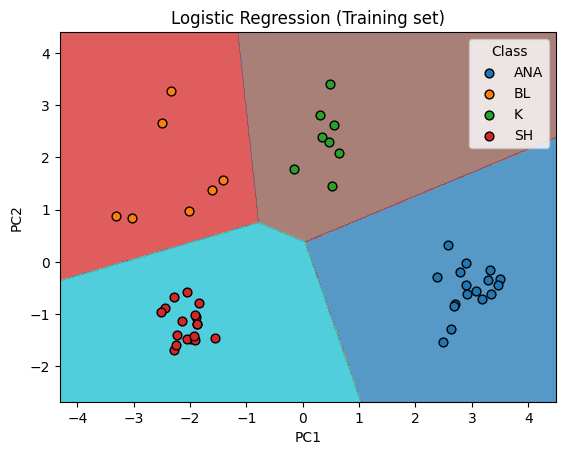

In [124]:
# Build a name -> integer mapping just for the contourf background
classes = np.unique(y_train) # ['ANA', 'BL', 'K', 'SH']
class_to_num = {name: i for i, name in enumerate(classes)}
print("Class mapping:", class_to_num)

X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

# Predict on the grid (returns strings), convert to integers for contourf
Z_strings = classifier.predict(np.array([X1.ravel(), X2.ravel()]).T)
Z_numeric = np.array([class_to_num[c] for c in Z_strings]).reshape(X1.shape)

plt.contourf(X1, X2, Z_numeric, alpha=0.75, cmap='tab10')
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# Scatter: iterate over string class names
for name in classes:
    mask = (y_set == name)
    plt.scatter(
        X_set[mask, 0], X_set[mask, 1],
        c=[plt.cm.tab10(class_to_num[name])],
        label=name,                 # <-- the string itself, no lookup
        edgecolor='k',
        s=40
    )

# table
plt.title('Logistic Regression (Training set)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Class')
plt.show()

In [ ]:
# loading score value
feature_names = dataset.columns[1:]
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=feature_names
)

print(loadings.round(3))
print("\nExplained variance per PC:")
print(pca.explained_variance_ratio_.round(3))

      PC1    PC2
Fe  0.407 -0.039
Ti  0.341  0.372
Ba  0.345 -0.081
Ca  0.303  0.431
K  -0.294  0.450
Mn  0.398  0.026
Rb -0.277  0.429
Sr  0.300  0.419
Y   0.000  0.065
Zr  0.309 -0.317

Explained variance per PC:
[0.538 0.214]


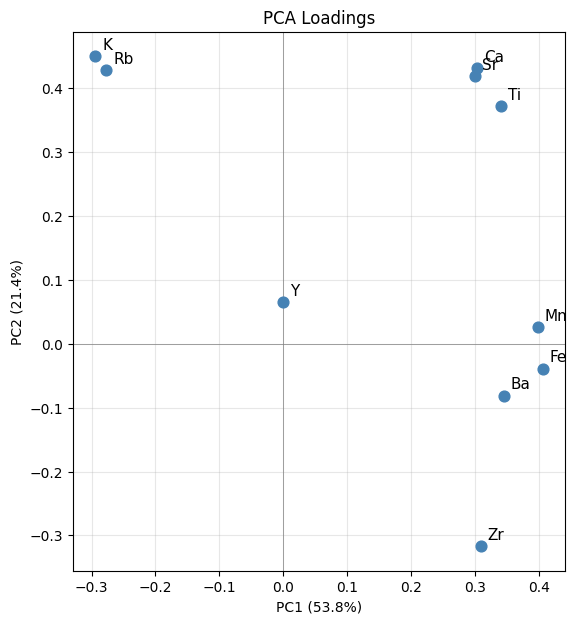

In [128]:
# plotting the loading score
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(loadings['PC1'], loadings['PC2'], s=60, color='steelblue', zorder=3)

# Label each point with its feature name
for feature in feature_names:
    ax.annotate(
        feature,
        xy=(loadings.loc[feature, 'PC1'], loadings.loc[feature, 'PC2']),
        xytext=(5, 5), textcoords='offset points',
        fontsize=11
    )

# Reference lines at zero
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA Loadings')
ax.set_aspect('equal')
plt.grid(alpha=0.3)
plt.show()

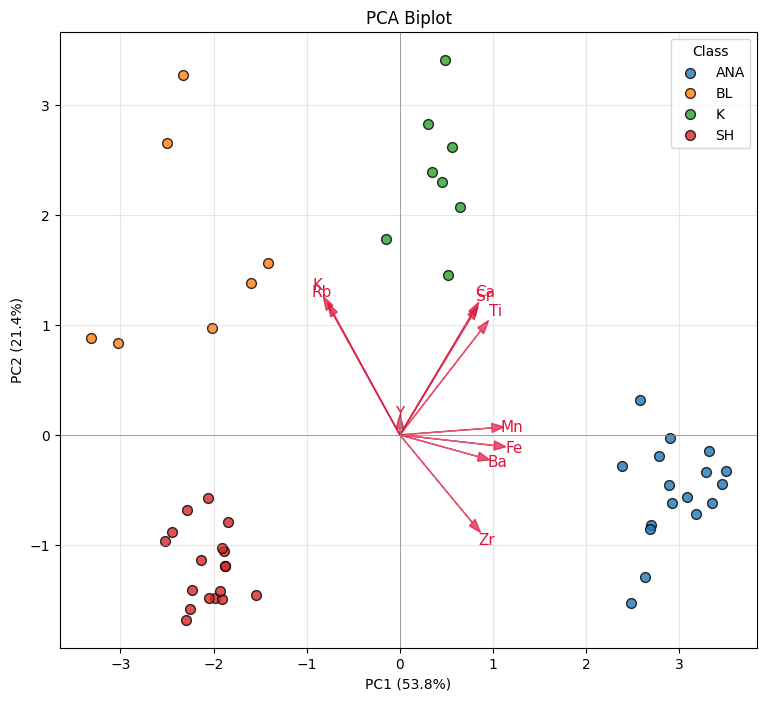

In [129]:
# plotting both the sample and loading score in one graph
# --- scores ---
X_pca = X_train                     # shape (n_samples, 2) — the PC scores
y_plot = y_train
classes = np.unique(y_plot)

# --- loadings ---
feature_names = dataset.columns[1:]
loadings_arr = pca.components_.T    # shape (n_features, 2)

fig, ax = plt.subplots(figsize=(9, 8))

# 1. Scatter the samples
for name in classes:
    mask = (y_plot == name)
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        label=name, s=50, edgecolor='k', alpha=0.8
    )

# 2. Scale arrows so they fit nicely on the same axes as the scatter
scale = np.abs(X_pca).max() * 0.8   # tweak this factor if arrows look too big/small

for feature, (dx, dy) in zip(feature_names, loadings_arr):
    ax.arrow(0, 0, dx*scale, dy*scale,
             head_width=scale*0.03, color='crimson', alpha=0.7, length_includes_head=True)
    ax.text(dx*scale*1.08, dy*scale*1.08, feature,
            color='crimson', fontsize=11, ha='center', va='center')

# 3. Reference lines
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA Biplot')
ax.legend(title='Class')
plt.grid(alpha=0.3)
plt.show()